# 🎯 RFM Customer Segmentation Analysis


In [ ]:
# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import timedelta
from mpl_toolkits.mplot3d import Axes3D
# Visual defaults
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a3e',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
})

SEGMENT_PALETTE = {
    'Champions':       '#f72585',
    'Loyal':           '#7209b7',
    'Needs Attention': '#3a86ff',
    'At Risk':         '#fb8500',
    'Lost':            '#6c757d',
}

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


## 📂 Load & Inspect Data

In [ ]:
#  2. LOAD DATA
df = pd.read_csv('sales_data_sample.csv')
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

print(f"Shape         : {df.shape}")
print(f"Date range    : {df['ORDERDATE'].min().date()} → {df['ORDERDATE'].max().date()}")
print(f"Unique orders : {df['ORDERNUMBER'].nunique()}")
print(f"Unique customers: {df['CUSTOMERNAME'].nunique()}")
print()
df.head(3)


Shape         : (1412, 21)
Date range    : 2003-01-06 → 2005-05-31
Unique orders : 1412
Unique customers: 92



,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10001,55,44.12,5,2426.60,2005-05-30,In Process,2,5,2005,...,206,S79_2424,Customer_001,555-7912,521 Main St,NYC,USA,Last12,First28,Small
1,10002,97,27.96,7,2712.12,2003-12-31,In Process,4,12,2003,...,212,S79_7873,Customer_001,555-4611,7360 Main St,Phoenix,USA,Last36,First1,Small
2,10003,74,51.18,5,3787.32,2003-06-17,Resolved,2,6,2003,...,119,S23_2519,Customer_001,555-7224,1585 Main St,Chicago,USA,Last45,First78,Medium


## 🧮 Calculate RFM Metrics

| Metric | Definition | Direction |
|--------|-----------|-----------|
| **Recency** | Days since last purchase | Lower = Better |
| **Frequency** | # unique orders placed | Higher = Better |
| **Monetary** | Total revenue generated | Higher = Better |


In [ ]:
# 3. RFM COMPUTATION
reference_date = df['ORDERDATE'].max() + timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

rfm = (
    df.groupby('CUSTOMERNAME')
    .agg(
        Recency  = ('ORDERDATE',   lambda x: (reference_date - x.max()).days),
        Frequency= ('ORDERNUMBER', 'nunique'),
        Monetary = ('SALES',       'sum')
    )
    .reset_index()
)

# Round monetary for readability
rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"\n📊 RFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
rfm.head()


Reference date: 2005-06-01

📊 RFM Summary Statistics:
       Recency  Frequency   Monetary
count    92.00      92.00      92.00
mean     77.48      15.35   56242.25
std     111.08       8.63   33570.88
min       1.00       1.00    3450.28
25%      14.75       9.00   30359.34
50%      35.00      14.00   54858.80
75%      87.25      21.00   77923.50
max     497.00      38.00  137169.20


,CUSTOMERNAME,Recency,Frequency,Monetary
0,Customer_001,2,28,83356.97
1,Customer_002,13,28,113814.42
2,Customer_003,25,33,137169.20
3,Customer_004,5,31,102994.05
4,Customer_005,22,26,80676.12


## 🏅— Quantile-Based Scoring (1–4)

`pd.qcut` splits each metric into 4 equal-frequency buckets.  
**Key inversion:** For Recency, score **4 = most recent** (lowest days).


In [ ]:


def safe_qcut(series, n=4, labels=None, ascending=True):
    """qcut with duplicate-edge handling via rank averaging."""
    try:
        result = pd.qcut(series, q=n, labels=labels, duplicates='drop')
        # Re-map to requested label count if bins were merged
        return result.cat.codes + 1
    except Exception:
        ranked = series.rank(method='first', ascending=ascending)
        return pd.qcut(ranked, q=n, labels=labels, duplicates='drop')

# R: invert so small recency → score 4
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first', ascending=True),
                          q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first', ascending=False),
                          q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first', ascending=False),
                          q=4, labels=[4, 3, 2, 1]).astype(int)

# Composite RFM score string (e.g. "444", "132")
rfm['RFM_Segment_Code'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

# Numeric aggregate score
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("Score distribution:")
print(rfm[['R_Score','F_Score','M_Score']].apply(pd.Series.value_counts).fillna(0).astype(int))
rfm[['CUSTOMERNAME','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Segment_Code']].head(10)


Score distribution:
   R_Score  F_Score  M_Score
4       23       23       23
3       23       23       23
2       23       23       23
1       23       23       23


,CUSTOMERNAME,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment_Code
0,Customer_001,2,28,83356.97,4,4,4,444
1,Customer_002,13,28,113814.42,4,4,4,444
2,Customer_003,25,33,137169.20,3,4,4,344
3,Customer_004,5,31,102994.05,4,4,4,444
4,Customer_005,22,26,80676.12,3,4,4,344
5,Customer_006,17,30,112306.44,3,4,4,344
6,Customer_007,11,38,133225.56,4,4,4,444
7,Customer_008,3,34,133465.07,4,4,4,444
8,Customer_009,2,28,120593.30,4,4,4,444
9,Customer_010,10,15,56559.20,4,3,3,433


## 🏷️ Segment Definition & Assignment

Five named segments are defined using R, F, M score thresholds:

| Segment | Logic | Description |
|---------|-------|-------------|
| **Champions** | R≥3 & F≥3 & M≥3 | Best customers — recent, frequent, high-value |
| **Loyal** | F≥3 & M≥3 | Frequent and valuable, may not be as recent |
| **At Risk** | R≤2 & F≥3 & M≥3 | Were top buyers — now drifting away |
| **Needs Attention** | R≥3 & F≤2 | Recent but infrequent — potential to grow |
| **Lost** | R≤2 & F≤2 & M≤2 | Haven't bought in a long time, low value |


In [ ]:
def assign_segment(row):
    R, F, M = row['R_Score'], row['F_Score'], row['M_Score']
    if R >= 3 and F >= 3 and M >= 3:
        return 'Champions'
    elif R <= 2 and F >= 3 and M >= 3:
        return 'At Risk'
    elif F >= 3 and M >= 3:
        return 'Loyal'
    elif R >= 3 and F <= 2:
        return 'Needs Attention'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Count check
print("Segment distribution:")
print(rfm['Segment'].value_counts())


Segment distribution:
Segment
Lost               37
Champions          30
Needs Attention    13
At Risk            12
Name: count, dtype: int64


## 📋 Segment Summary Table

In [ ]:
# ─── 6. SUMMARY TABLE ────────────────────────────────────────────────────────
summary = (
    rfm.groupby('Segment')
    .agg(
        Customer_Count  = ('CUSTOMERNAME',  'count'),
        Avg_Recency_Days= ('Recency',        'mean'),
        Avg_Frequency   = ('Frequency',      'mean'),
        Avg_Monetary    = ('Monetary',        'mean'),
        Total_Revenue   = ('Monetary',        'sum'),
    )
    .round(1)
    .sort_values('Avg_Monetary', ascending=False)
    .reset_index()
)

summary['Revenue_Share_%'] = (
    (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(1)
)

print("\n📊 SEGMENT SUMMARY TABLE")
print("=" * 80)
print(summary.to_string(index=False))
summary



📊 SEGMENT SUMMARY TABLE
        Segment  Customer_Count  Avg_Recency_Days  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_Share_%
      Champions              30              16.4           23.3       87169.3      2615078.8             50.5
        At Risk              12              69.3           21.7       79747.1       956965.1             18.5
Needs Attention              13              17.2           11.6       43367.5       563778.1             10.9
           Lost              37             150.8            8.1       28066.6      1038465.3             20.1


,Segment,Customer_Count,Avg_Recency_Days,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%
0,Champions,30,16.4,23.3,87169.3,2615078.8,50.5
1,At Risk,12,69.3,21.7,79747.1,956965.1,18.5
2,Needs Attention,13,17.2,11.6,43367.5,563778.1,10.9
3,Lost,37,150.8,8.1,28066.6,1038465.3,20.1


## 📊 Visualization 1 — Customer Count per Segment

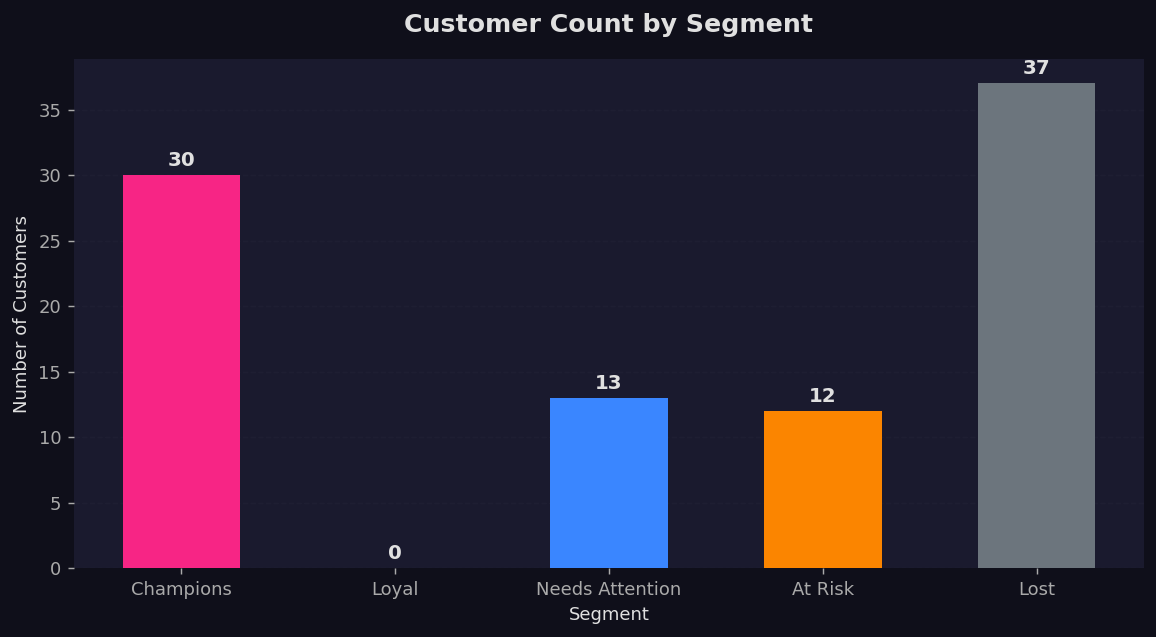

✅ Saved: seg_bar_chart.png


In [ ]:
# ─── 7. BAR CHART ─────────────────────────────────────────────────────────────
seg_order = list(SEGMENT_PALETTE.keys())
counts = rfm['Segment'].value_counts().reindex(seg_order).fillna(0)
colors = [SEGMENT_PALETTE[s] for s in seg_order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(seg_order, counts, color=colors, edgecolor='none', width=0.55)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4, f'{int(val)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Customer Count by Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Segment')
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.spines[['top','right','left','bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('seg_bar_chart.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print("✅ Saved: seg_bar_chart.png")


## 📊 Visualization 2 — Recency vs Monetary (colored by Segment)

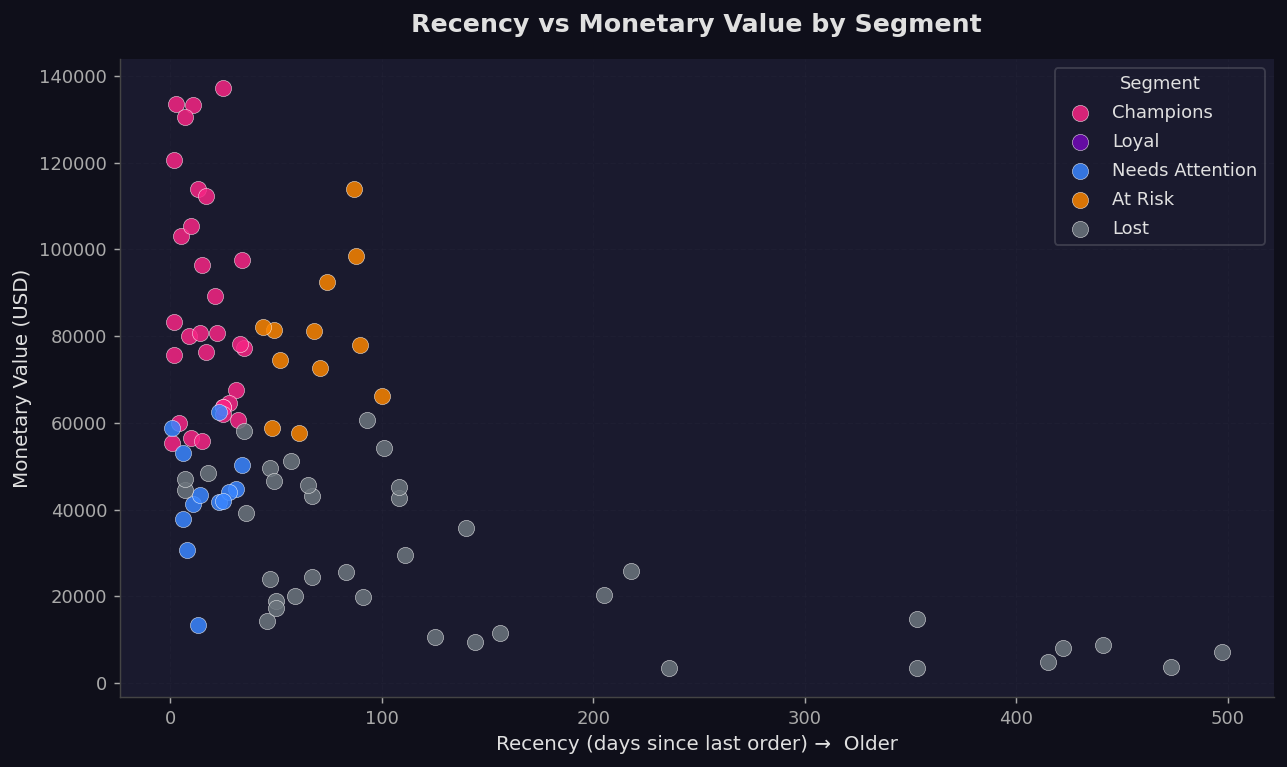

✅ Saved: seg_scatter.png


In [ ]:
# ─── 8. SCATTER PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for seg, color in SEGMENT_PALETTE.items():
    subset = rfm[rfm['Segment'] == seg]
    ax.scatter(subset['Recency'], subset['Monetary'],
               c=color, label=seg, s=80, alpha=0.85, edgecolors='white', linewidths=0.3)

ax.set_title('Recency vs Monetary Value by Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Recency (days since last order) →  Older', fontsize=11)
ax.set_ylabel('Monetary Value (USD)', fontsize=11)
ax.legend(title='Segment', framealpha=0.2, labelspacing=0.6)
ax.yaxis.grid(True, alpha=0.25)
ax.xaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('seg_scatter.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✅ Saved: seg_scatter.png")


## 📊 Visualization 3 — Average RFM Scores Heatmap per Segment

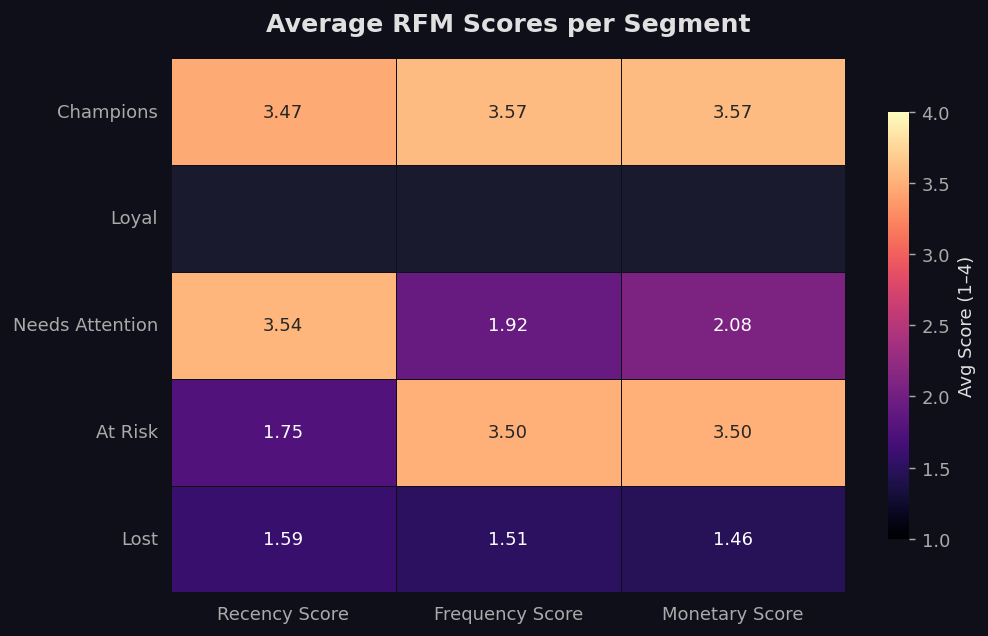

✅ Saved: seg_heatmap.png


In [ ]:
# ─── 9. HEATMAP ───────────────────────────────────────────────────────────────
heat_data = (
    rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']]
    .mean()
    .round(2)
    .reindex(seg_order)
)
heat_data.columns = ['Recency Score', 'Frequency Score', 'Monetary Score']

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heat_data, annot=True, fmt='.2f', cmap='magma',
    linewidths=0.5, linecolor='#0f0f1a',
    vmin=1, vmax=4, ax=ax,
    cbar_kws={'label': 'Avg Score (1–4)', 'shrink': 0.8}
)
ax.set_title('Average RFM Scores per Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)
plt.tight_layout()
plt.savefig('seg_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✅ Saved: seg_heatmap.png")


## ⭐ Bonus — 3D Scatter Plot (Recency × Frequency × Monetary)

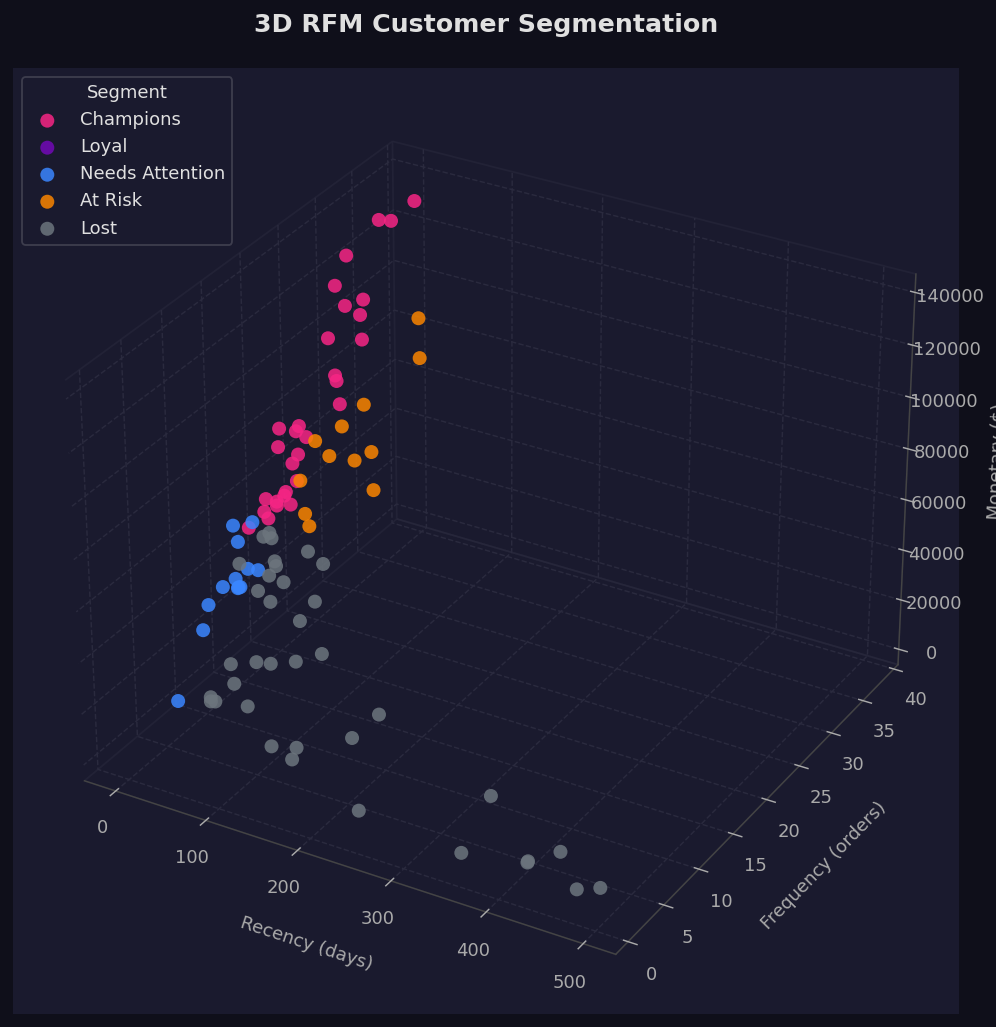

✅ Saved: seg_3d_scatter.png


In [ ]:
# ─── 10. 3D SCATTER ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 8), facecolor='#0f0f1a')
ax3d = fig.add_subplot(111, projection='3d', facecolor='#1a1a2e')

for seg, color in SEGMENT_PALETTE.items():
    subset = rfm[rfm['Segment'] == seg]
    ax3d.scatter(
        subset['Recency'], subset['Frequency'], subset['Monetary'],
        c=color, label=seg, s=60, alpha=0.85, edgecolors='none'
    )

ax3d.set_xlabel('Recency (days)', color='#aaa', labelpad=10)
ax3d.set_ylabel('Frequency (orders)', color='#aaa', labelpad=10)
ax3d.set_zlabel('Monetary ($)', color='#aaa', labelpad=10)
ax3d.set_title('3D RFM Customer Segmentation', color='#e0e0e0',
               fontsize=14, fontweight='bold', pad=20)
ax3d.tick_params(colors='#aaa')
ax3d.xaxis.pane.fill = ax3d.yaxis.pane.fill = ax3d.zaxis.pane.fill = False
ax3d.xaxis.pane.set_edgecolor('#2a2a3e')
ax3d.yaxis.pane.set_edgecolor('#2a2a3e')
ax3d.zaxis.pane.set_edgecolor('#2a2a3e')

legend = ax3d.legend(title='Segment', framealpha=0.2, loc='upper left')
plt.setp(legend.get_title(), color='#e0e0e0')
plt.tight_layout()
plt.savefig('seg_3d_scatter.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✅ Saved: seg_3d_scatter.png")


## 💡 Marketing Strategy per Segment

| Segment | Strategy | Tactics |
|---------|----------|---------|
| 🏆 **Champions** | Reward & Retain | VIP loyalty program, early access, referral bonuses |
| 💜 **Loyal** | Upsell & Cross-sell | Bundle offers, premium tier nudge, thank-you discounts |
| 🔵 **Needs Attention** | Engage & Educate | Personalized product recs, onboarding flows, check-in emails |
| 🟠 **At Risk** | Win-Back Campaign | "We miss you" emails, limited-time discount, feedback survey |
| ⚫ **Lost** | Reactivation or Sunset | Last-chance offer, opt-in re-permission, ROI evaluation |


In [ ]:
#  11. MARKETING STRATEGY TABLE
marketing = pd.DataFrame({
    'Segment': ['Champions', 'Loyal', 'Needs Attention', 'At Risk', 'Lost'],
    'Priority': ['🔴 Critical', '🟠 High', '🟡 Medium', '🔴 Critical', '🟢 Low'],
    'Primary Action': [
        'VIP rewards program + referral bonuses',
        'Upsell to premium tier + bundle offers',
        'Personalized email nurture + tutorials',
        'Win-back campaign + special discount',
        'Last-chance reactivation or sunset'
    ],
    'KPI to Track': [
        'Retention rate, CLV growth',
        'AOV increase, frequency uplift',
        'Repeat purchase rate',
        'Re-engagement rate, churn reduction',
        'Reactivation rate, unsubscribe rate'
    ],
    'Expected ROI': ['Very High', 'High', 'Medium', 'High', 'Low']
})
print(marketing.to_string(index=False))
marketing


        Segment   Priority                         Primary Action                        KPI to Track Expected ROI
      Champions 🔴 Critical VIP rewards program + referral bonuses          Retention rate, CLV growth    Very High
          Loyal     🟠 High Upsell to premium tier + bundle offers      AOV increase, frequency uplift         High
Needs Attention   🟡 Medium Personalized email nurture + tutorials                Repeat purchase rate       Medium
        At Risk 🔴 Critical   Win-back campaign + special discount Re-engagement rate, churn reduction         High
           Lost      🟢 Low     Last-chance reactivation or sunset Reactivation rate, unsubscribe rate          Low


,Segment,Priority,Primary Action,KPI to Track,Expected ROI
0,Champions,🔴 Critical,VIP rewards program + referral bonuses,"Retention rate, CLV growth",Very High
1,Loyal,🟠 High,Upsell to premium tier + bundle offers,"AOV increase, frequency uplift",High
2,Needs Attention,🟡 Medium,Personalized email nurture + tutorials,Repeat purchase rate,Medium
3,At Risk,🔴 Critical,Win-back campaign + special discount,"Re-engagement rate, churn reduction",High
4,Lost,🟢 Low,Last-chance reactivation or sunset,"Reactivation rate, unsubscribe rate",Low


## 💾 Bonus — Export RFM Table as CSV Report

In [ ]:
# 12. EXPORT
export_cols = [
    'CUSTOMERNAME', 'Recency', 'Frequency', 'Monetary',
    'R_Score', 'F_Score', 'M_Score', 'RFM_Segment_Code', 'RFM_Score', 'Segment'
]
rfm_export = rfm[export_cols].sort_values('RFM_Score', ascending=False)
rfm_export.to_csv('rfm_report.csv', index=False)

print(f"✅ Exported rfm_report.csv — {len(rfm_export)} customers")
print()
print("📊 Final segment breakdown:")
final_summary = rfm.groupby('Segment').agg(
    Customers=('CUSTOMERNAME','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean'),
    Revenue_Share=('Monetary', lambda x: round(x.sum()/rfm['Monetary'].sum()*100,1))
).round(1).sort_values('Revenue_Share', ascending=False)
print(final_summary.to_string())


✅ Exported rfm_report.csv — 92 customers

📊 Final segment breakdown:
                 Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Revenue_Share
Segment                                                                            
Champions               30         16.4           23.3       87169.3           50.5
Lost                    37        150.8            8.1       28066.6           20.1
At Risk                 12         69.3           21.7       79747.1           18.5
Needs Attention         13         17.2           11.6       43367.5           10.9


## ✅ Conclusion

This RFM pipeline successfully:

1. **Computed** Recency, Frequency and Monetary for all 92 customers from raw transactions
2. **Scored** each metric on a 1–4 scale using quantile binning, with proper recency inversion
3. **Segmented** customers into 5 actionable groups: Champions, Loyal, Needs Attention, At Risk, Lost
4. **Visualized** the segments across multiple dimensions (bar, scatter, heatmap, 3D)
5. **Exported** a complete CSV report ready for the marketing team

### Key Takeaways
- **Champions** drive disproportionate revenue — protect them at all costs
- **At Risk** customers represent urgent recovery opportunities with high ROI
- **Lost** customers require cost-benefit evaluation before investing reactivation spend
- **Needs Attention** customers are low-hanging fruit — they're recent, just need engagement

